# BCB ROC-AUC by Graph Type and Clone Type

This notebook evaluates AST, CFG, DDG, PDG, and CPG as standalone continuous predictors, completely separate from the Random Forest pipeline.

It can run standalone: if no row-level DataFrame is already loaded, it reads the existing `pair_scores_trained_*_pss_wasserstein.csv` artifacts from `outputs/bcb` and uses their row-level similarity scores.

A purely aggregated count table is not enough for ROC-AUC, because ROC needs one score and one label per pair.

In [13]:
from __future__ import annotations

import math
import sys
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, roc_curve

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "spectral_code").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import output_root_for

sns.set_theme(style="whitegrid", context="notebook")

GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]

# Used when no row-level DataFrame is already available in memory.
# The notebook will read pair_scores_trained_* CSVs from outputs/bcb.
ROC_METRIC = "pss"
ROC_K_EIGEN = "full"
PAIR_SCORE_CHUNKSIZE = 500_000
PAIR_SCORE_VARIANTS = [
    ("Type 1", "1"),
    ("Type 2", "2"),
    ("Type 3 All", "3/all"),
    ("Type 3 Moderate", "3/moderate"),
    ("Type 3 Strong", "3/strong"),
    ("Type 3 Very Strong", "3/very_strong"),
    ("Type 4", "4"),
]

# Used only when the notebook has to build scores from eigenvalue_counts_df.
# Options: min_count, mean_count, max_count, neg_abs_diff_count
COUNT_SCORE_MODE = "min_count"

# Keep this False for honest intrinsic analysis. If True, curves whose raw AUC is
# below 0.5 are plotted with the score direction flipped and marked as oriented.
AUTO_ORIENT_SCORES = False

RANDOM_BASELINE_KWARGS = dict(color="0.35", linestyle="--", linewidth=1, alpha=0.65)


## Helpers

In [14]:
def first_existing(columns: Iterable[str], candidates: Iterable[str]) -> str | None:
    lookup = {str(col).lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


def normalize_pair_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    aliases = {
        "left_id": ["left_id", "id1", "function_id_1", "method_id_1", "left", "method1", "func1"],
        "right_id": ["right_id", "id2", "function_id_2", "method_id_2", "right", "method2", "func2"],
        "label": ["label", "target", "y", "is_clone", "clone", "ground_truth"],
        "clone_type": ["clone_type", "type", "clone_category", "label_type"],
        "source_variant": ["source_variant", "variant", "dataset", "split_name", "type_name"],
    }
    rename_map = {}
    for canonical, candidates in aliases.items():
        if canonical not in out.columns:
            found = first_existing(out.columns, candidates)
            if found is not None:
                rename_map[found] = canonical
    if rename_map:
        out = out.rename(columns=rename_map)
    return out


def normalize_graph_type(value) -> str:
    return str(value).strip().lower()


def canonical_clone_group(row: pd.Series) -> str:
    """Return the evaluation group a pair belongs to.

    For positive pairs this is their clone type. For negative pairs, this should
    usually be the clone-type split they were sampled into, stored in source_variant.
    """
    raw_parts = []
    for col in ("source_variant", "clone_type"):
        if col in row and pd.notna(row[col]):
            raw_parts.append(str(row[col]).strip().lower())
    raw = " ".join(raw_parts)

    if "very" in raw and "strong" in raw:
        return "Type 3 Very Strong"
    if "moderate" in raw:
        return "Type 3 Moderate"
    if "strong" in raw:
        return "Type 3 Strong"
    if "type3" in raw or "type_3" in raw or raw == "3" or "type 3" in raw:
        return "Type 3 All"
    if "type1" in raw or "type_1" in raw or raw == "1" or "type 1" in raw:
        return "Type 1"
    if "type2" in raw or "type_2" in raw or raw == "2" or "type 2" in raw:
        return "Type 2"
    if "type4" in raw or "type_4" in raw or raw == "4" or "type 4" in raw:
        return "Type 4"
    if pd.notna(row.get("label", np.nan)) and int(row["label"]) == 0:
        return "Non-Clone Pool"
    return "Unknown"


def standardize_pair_graph_scores(df: pd.DataFrame, *, score_column: str | None = None) -> pd.DataFrame:
    out = normalize_pair_columns(df)
    if "graph_type" not in out.columns:
        graph_col = first_existing(out.columns, ["graph", "graph_name", "layer", "graph_kind"])
        if graph_col is not None:
            out = out.rename(columns={graph_col: "graph_type"})

    score_candidates = [
        score_column,
        "score",
        "similarity",
        "pss",
        "wasserstein_similarity",
        "spectral_similarity",
        "min_count",
        "mean_count",
        "max_count",
        "eigenvalue_count_score",
    ]
    score_candidates = [col for col in score_candidates if col]
    found_score = first_existing(out.columns, score_candidates)
    if found_score is not None and found_score != "score":
        out = out.rename(columns={found_score: "score"})

    required = {"left_id", "right_id", "label", "graph_type", "score"}
    missing = sorted(required.difference(out.columns))
    if missing:
        raise ValueError(
            "ROC-AUC needs row-level pair scores. Missing columns: "
            + ", ".join(missing)
            + ". Provide pair_graph_scores_df, or pairs_df + eigenvalue_counts_df."
        )

    out = out.copy()
    out["graph_type"] = out["graph_type"].map(normalize_graph_type)
    out["label"] = pd.to_numeric(out["label"], errors="coerce").astype("Int64")
    out["score"] = pd.to_numeric(out["score"], errors="coerce")
    out = out[out["graph_type"].isin(GRAPH_TYPES)].dropna(subset=["label", "score"])
    out["label"] = out["label"].astype(int)
    out["clone_group"] = out.apply(canonical_clone_group, axis=1)
    return out


def standardize_eigenvalue_counts(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    method_col = first_existing(out.columns, ["method_id", "function_id", "id", "code_id"])
    graph_col = first_existing(out.columns, ["graph_type", "graph", "graph_name", "layer"])
    count_col = first_existing(out.columns, ["eigenvalue_count", "num_eigenvalues", "n_eigenvalues", "count", "spectral_count"])

    if method_col is None:
        raise ValueError("eigenvalue_counts_df must include a method/function id column.")

    if graph_col is not None and count_col is not None:
        out = out.rename(columns={method_col: "method_id", graph_col: "graph_type", count_col: "eigenvalue_count"})
        out["graph_type"] = out["graph_type"].map(normalize_graph_type)
        out["eigenvalue_count"] = pd.to_numeric(out["eigenvalue_count"], errors="coerce")
        return out[[col for col in ["source_variant", "method_id", "graph_type", "eigenvalue_count"] if col in out.columns]]

    # Wide format fallback: ast_eigenvalue_count, cfg_count, pdg_num_eigenvalues, ...
    wide_rows = []
    for graph_type in GRAPH_TYPES:
        candidates = [
            f"{graph_type}_eigenvalue_count",
            f"{graph_type}_num_eigenvalues",
            f"{graph_type}_n_eigenvalues",
            f"{graph_type}_count",
        ]
        found = first_existing(out.columns, candidates)
        if found is None:
            continue
        cols = [method_col, found]
        if "source_variant" in out.columns:
            cols.insert(0, "source_variant")
        part = out[cols].copy().rename(columns={method_col: "method_id", found: "eigenvalue_count"})
        part["graph_type"] = graph_type
        wide_rows.append(part)

    if not wide_rows:
        raise ValueError("Could not find graph-level eigenvalue count columns in eigenvalue_counts_df.")
    long_df = pd.concat(wide_rows, ignore_index=True)
    long_df["eigenvalue_count"] = pd.to_numeric(long_df["eigenvalue_count"], errors="coerce")
    return long_df


def build_pair_graph_scores_from_counts(
    pairs_df: pd.DataFrame,
    eigenvalue_counts_df: pd.DataFrame,
    *,
    graph_types: list[str] = GRAPH_TYPES,
    score_mode: str = COUNT_SCORE_MODE,
) -> pd.DataFrame:
    pairs = normalize_pair_columns(pairs_df)
    required = {"left_id", "right_id", "label"}
    missing = sorted(required.difference(pairs.columns))
    if missing:
        raise ValueError("pairs_df is missing columns: " + ", ".join(missing))

    counts = standardize_eigenvalue_counts(eigenvalue_counts_df)
    counts = counts[counts["graph_type"].isin(graph_types)].dropna(subset=["eigenvalue_count"])

    use_variant_key = "source_variant" in pairs.columns and "source_variant" in counts.columns
    left_keys = ["source_variant", "left_id"] if use_variant_key else ["left_id"]
    right_keys = ["source_variant", "right_id"] if use_variant_key else ["right_id"]

    frames = []
    for graph_type in graph_types:
        graph_counts = counts[counts["graph_type"] == graph_type].copy()
        left_counts = graph_counts.rename(columns={"method_id": "left_id", "eigenvalue_count": "left_count"})
        right_counts = graph_counts.rename(columns={"method_id": "right_id", "eigenvalue_count": "right_count"})

        left_cols = [col for col in ["source_variant", "left_id", "left_count"] if col in left_counts.columns]
        right_cols = [col for col in ["source_variant", "right_id", "right_count"] if col in right_counts.columns]

        merged = pairs.merge(left_counts[left_cols], on=left_keys, how="left")
        merged = merged.merge(right_counts[right_cols], on=right_keys, how="left")
        merged["graph_type"] = graph_type
        merged["min_count"] = merged[["left_count", "right_count"]].min(axis=1)
        merged["mean_count"] = merged[["left_count", "right_count"]].mean(axis=1)
        merged["max_count"] = merged[["left_count", "right_count"]].max(axis=1)
        merged["neg_abs_diff_count"] = -1.0 * (merged["left_count"] - merged["right_count"]).abs()
        if score_mode not in {"min_count", "mean_count", "max_count", "neg_abs_diff_count"}:
            raise ValueError(f"Unknown score_mode: {score_mode}")
        merged["score"] = merged[score_mode]
        frames.append(merged)

    score_df = pd.concat(frames, ignore_index=True)
    score_df = standardize_pair_graph_scores(score_df, score_column="score")
    return score_df


## Load or Build Row-Level Scores

In [15]:
def pair_score_csv_for_variant(variant: str) -> Path | None:
    root = output_root_for("bcb", variant)
    candidates = sorted(root.glob("pair_scores_trained_*_pss_wasserstein.csv"))
    if not candidates:
        warnings.warn(f"No pair-score CSV found under {root}")
        return None
    if len(candidates) > 1:
        warnings.warn(f"Multiple pair-score CSVs found under {root}; using {candidates[0].name}")
    return candidates[0]


def load_pair_scores_from_artifacts(
    *,
    variants: list[tuple[str, str]] = PAIR_SCORE_VARIANTS,
    graph_types: list[str] = GRAPH_TYPES,
    metric: str = ROC_METRIC,
    k_eigen: str = ROC_K_EIGEN,
    chunksize: int = PAIR_SCORE_CHUNKSIZE,
) -> pd.DataFrame:
    """Load row-level scores from existing BCB pair-score artifacts.

    This is the standalone path for the notebook. The generated tuning pair-score
    CSVs already contain one score per pair/graph/metric/k, which is exactly what
    ROC-AUC needs.
    """
    usecols = ["left_id", "right_id", "label", "graph_type", "k_eigen", "metric", "score"]
    graph_set = {str(graph).lower() for graph in graph_types}
    frames = []
    load_rows = []

    for clone_label, variant in variants:
        csv_path = pair_score_csv_for_variant(variant)
        if csv_path is None:
            continue

        kept_for_variant = 0
        for chunk in pd.read_csv(
            csv_path,
            usecols=usecols,
            dtype={"left_id": str, "right_id": str, "graph_type": str, "k_eigen": str, "metric": str},
            chunksize=chunksize,
        ):
            chunk["graph_type"] = chunk["graph_type"].str.lower()
            mask = chunk["graph_type"].isin(graph_set)
            if metric:
                mask &= chunk["metric"].astype(str).eq(str(metric))
            if k_eigen:
                mask &= chunk["k_eigen"].astype(str).eq(str(k_eigen))
            chunk = chunk.loc[mask].copy()
            if chunk.empty:
                continue
            chunk["source_variant"] = variant
            chunk["clone_type"] = clone_label
            frames.append(chunk)
            kept_for_variant += len(chunk)

        load_rows.append({"clone_group": clone_label, "variant": variant, "rows_loaded": kept_for_variant, "csv": str(csv_path)})

    load_report_df = pd.DataFrame(load_rows)
    display(load_report_df)
    if not frames:
        raise FileNotFoundError(
            "No pair-score rows were loaded. Check that pair_scores_trained_*_pss_wasserstein.csv exists "
            "and that ROC_METRIC / ROC_K_EIGEN / GRAPH_TYPES match the CSV contents."
        )

    loaded = pd.concat(frames, ignore_index=True)
    return standardize_pair_graph_scores(loaded, score_column="score")


def get_roc_score_dataframe() -> pd.DataFrame:
    """Pick the best available row-level source, or load BCB artifacts directly."""
    if "pair_graph_scores_df" in globals():
        print("Using row-level pair_graph_scores_df.")
        return standardize_pair_graph_scores(pair_graph_scores_df)

    if "per_graph_pair_threshold_df" in globals():
        try:
            score_df = standardize_pair_graph_scores(per_graph_pair_threshold_df)
            print("Using row-level per_graph_pair_threshold_df.")
            return score_df
        except ValueError as exc:
            warnings.warn(
                "per_graph_pair_threshold_df is present, but it does not look row-level enough for ROC-AUC. "
                f"Reason: {exc}"
            )

    if "pairs_df" in globals() and "eigenvalue_counts_df" in globals():
        print(f"Building row-level scores from pairs_df + eigenvalue_counts_df using {COUNT_SCORE_MODE}.")
        return build_pair_graph_scores_from_counts(pairs_df, eigenvalue_counts_df)

    print("No in-memory row-level DataFrame found; loading existing BCB pair-score CSV artifacts.")
    print(f"Using metric={ROC_METRIC!r}, k_eigen={ROC_K_EIGEN!r}, graphs={GRAPH_TYPES}")
    return load_pair_scores_from_artifacts()


score_df = get_roc_score_dataframe()
score_df = score_df[score_df["clone_group"] != "Unknown"].copy()

print(f"Rows: {len(score_df):,}")
display(score_df.groupby(["clone_group", "graph_type", "label"]).size().rename("pairs").reset_index())
display(score_df.head())


No in-memory row-level DataFrame found; loading existing BCB pair-score CSV artifacts.
Using metric='pss', k_eigen='full', graphs=['ast', 'cfg', 'ddg', 'pdg', 'cpg']


,clone_group,variant,rows_loaded,csv
0,Type 1,1,458727,C:\Users\koush\PyProjects\spectrals\outputs\bc...
1,Type 2,2,41059,C:\Users\koush\PyProjects\spectrals\outputs\bc...
2,Type 3 All,3/all,1059639,C:\Users\koush\PyProjects\spectrals\outputs\bc...
3,Type 3 Moderate,3/moderate,860402,C:\Users\koush\PyProjects\spectrals\outputs\bc...
4,Type 3 Strong,3/strong,167158,C:\Users\koush\PyProjects\spectrals\outputs\bc...
5,Type 3 Very Strong,3/very_strong,32079,C:\Users\koush\PyProjects\spectrals\outputs\bc...
6,Type 4,4,9394186,C:\Users\koush\PyProjects\spectrals\outputs\bc...


Rows: 12,013,250


,clone_group,graph_type,label,pairs
0,Type 1,ast,0,45873
1,Type 1,ast,1,45873
2,Type 1,cfg,0,45873
3,Type 1,cfg,1,45873
4,Type 1,cpg,0,45873
...,...,...,...,...
65,Type 4,cpg,1,939436
66,Type 4,ddg,0,939342
67,Type 4,ddg,1,939356
68,Type 4,pdg,0,939436


,left_id,right_id,label,graph_type,k_eigen,metric,score,source_variant,clone_type,clone_group
0,4188859,23677116,0,ast,full,pss,0.438531,1,Type 1,Type 1
1,359836,682346,1,ast,full,pss,1.000000,1,Type 1,Type 1
2,1238799,23677118,0,ast,full,pss,0.387270,1,Type 1,Type 1
3,110360,574106,1,ast,full,pss,1.000000,1,Type 1,Type 1
4,10709892,23677116,0,ast,full,pss,0.437707,1,Type 1,Type 1


## ROC-AUC Calculation

In [16]:
def compute_roc_curves(score_df: pd.DataFrame, graph_types: list[str] = GRAPH_TYPES):
    curves = {}
    summary_rows = []
    skipped_rows = []

    for clone_group, group_df in score_df.groupby("clone_group", sort=True):
        for graph_type in graph_types:
            sub = group_df[group_df["graph_type"] == graph_type].dropna(subset=["label", "score"])
            positives = int((sub["label"] == 1).sum())
            negatives = int((sub["label"] == 0).sum())
            if sub.empty or sub["label"].nunique() < 2:
                skipped_rows.append(
                    {
                        "clone_group": clone_group,
                        "graph_type": graph_type,
                        "pairs": len(sub),
                        "positives": positives,
                        "negatives": negatives,
                        "reason": "needs both positive and negative labels",
                    }
                )
                continue

            y_true = sub["label"].astype(int).to_numpy()
            y_score = sub["score"].astype(float).to_numpy()
            fpr, tpr, thresholds = roc_curve(y_true, y_score)
            auc_value = auc(fpr, tpr)
            oriented = False

            if AUTO_ORIENT_SCORES and auc_value < 0.5:
                y_score = -y_score
                fpr, tpr, thresholds = roc_curve(y_true, y_score)
                auc_value = auc(fpr, tpr)
                oriented = True

            curves[(clone_group, graph_type)] = {
                "fpr": fpr,
                "tpr": tpr,
                "thresholds": thresholds,
                "auc": auc_value,
                "pairs": len(sub),
                "positives": positives,
                "negatives": negatives,
                "oriented": oriented,
            }
            summary_rows.append(
                {
                    "clone_group": clone_group,
                    "graph_type": graph_type.upper(),
                    "auc": auc_value,
                    "pairs": len(sub),
                    "positives": positives,
                    "negatives": negatives,
                    "score_oriented": oriented,
                }
            )

    roc_summary_df = pd.DataFrame(summary_rows).sort_values(["clone_group", "graph_type"]).reset_index(drop=True)
    skipped_roc_df = pd.DataFrame(skipped_rows)
    return roc_summary_df, skipped_roc_df, curves


roc_summary_df, skipped_roc_df, roc_curves = compute_roc_curves(score_df)
display(roc_summary_df)

if not skipped_roc_df.empty:
    print("Skipped groups:")
    display(skipped_roc_df)

,clone_group,graph_type,auc,pairs,positives,negatives,score_oriented
0,Type 1,AST,1.000000,91746,45873,45873,False
1,Type 1,CFG,0.998524,91746,45873,45873,False
2,Type 1,CPG,1.000000,91746,45873,45873,False
3,Type 1,DDG,1.000000,91743,45873,45870,False
4,Type 1,PDG,1.000000,91746,45873,45873,False
5,Type 2,AST,1.000000,8212,4106,4106,False
6,Type 2,CFG,0.998179,8212,4106,4106,False
7,Type 2,CPG,1.000000,8212,4106,4106,False
8,Type 2,DDG,1.000000,8211,4106,4105,False
9,Type 2,PDG,1.000000,8212,4106,4106,False


## ROC Curves

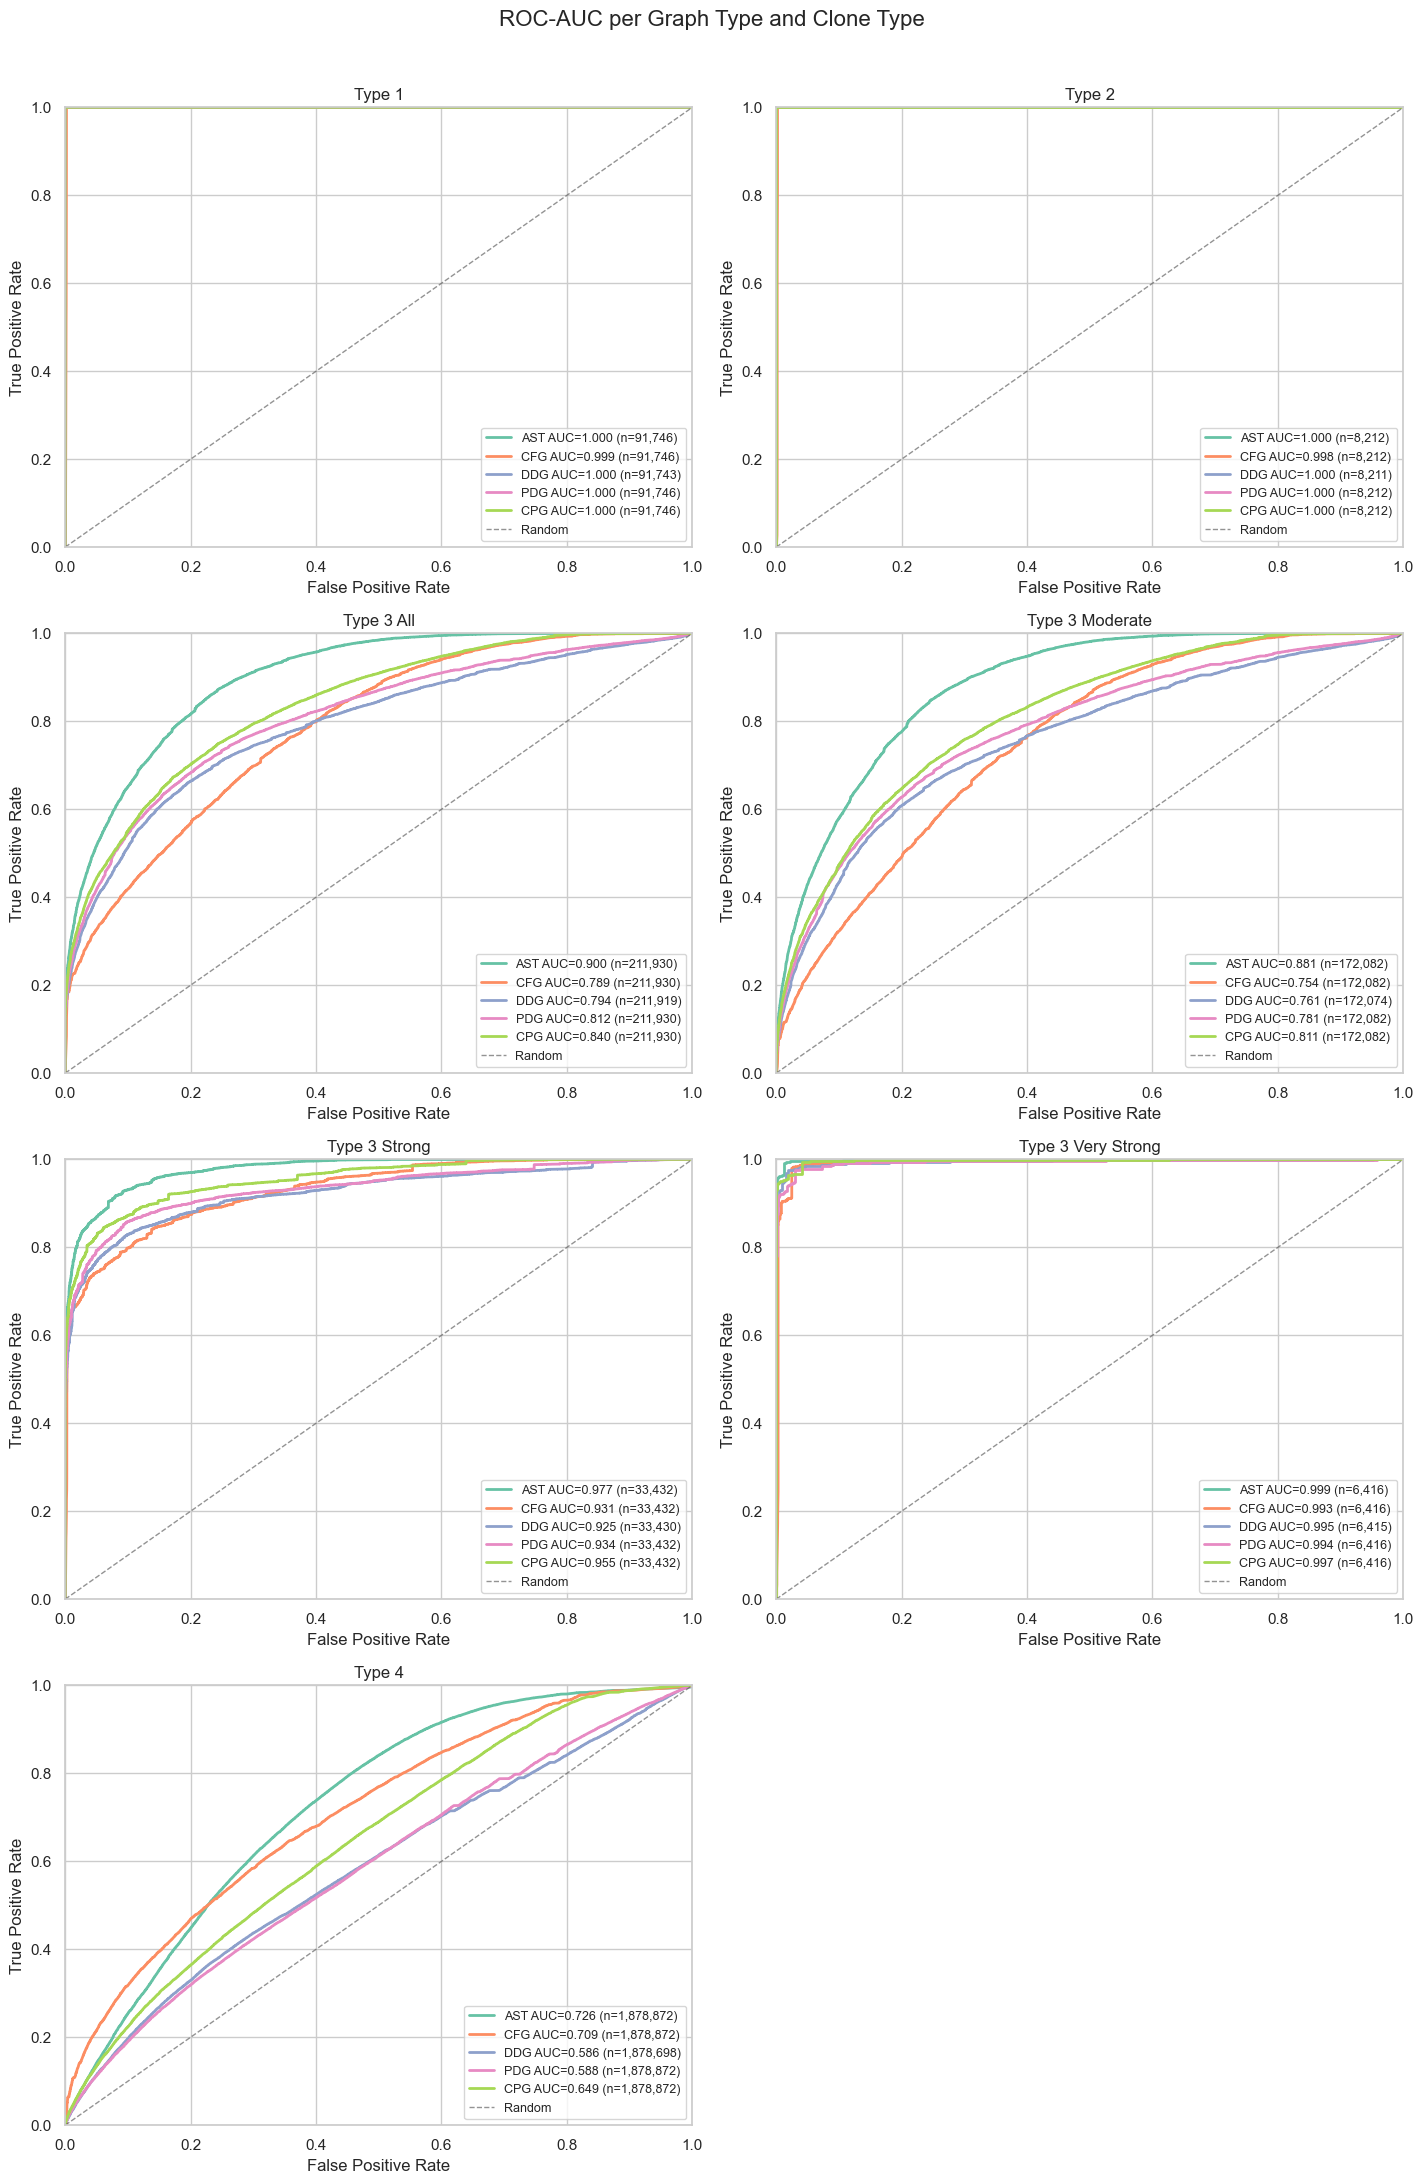

In [17]:
def plot_roc_by_clone_group(roc_summary_df: pd.DataFrame, roc_curves: dict, graph_types: list[str] = GRAPH_TYPES):
    clone_groups = list(roc_summary_df["clone_group"].drop_duplicates())
    if not clone_groups:
        raise ValueError("No ROC curves were computed. Check that each clone group has positive and negative pairs.")

    ncols = 2
    nrows = math.ceil(len(clone_groups) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7.2 * ncols, 5.4 * nrows), squeeze=False)
    palette = dict(zip(graph_types, sns.color_palette("Set2", n_colors=len(graph_types))))

    for ax, clone_group in zip(axes.flat, clone_groups):
        for graph_type in graph_types:
            curve = roc_curves.get((clone_group, graph_type))
            if curve is None:
                continue
            label = f"{graph_type.upper()} AUC={curve['auc']:.3f} (n={curve['pairs']:,})"
            if curve["oriented"]:
                label += " oriented"
            ax.plot(curve["fpr"], curve["tpr"], linewidth=2, color=palette[graph_type], label=label)

        ax.plot([0, 1], [0, 1], **RANDOM_BASELINE_KWARGS, label="Random")
        ax.set_title(clone_group)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower right", fontsize=9)

    for ax in axes.flat[len(clone_groups):]:
        ax.axis("off")

    fig.suptitle("ROC-AUC per Graph Type and Clone Type", y=1.01, fontsize=16)
    fig.tight_layout()
    return fig


fig = plot_roc_by_clone_group(roc_summary_df, roc_curves)
plt.show()

## AUC Comparison

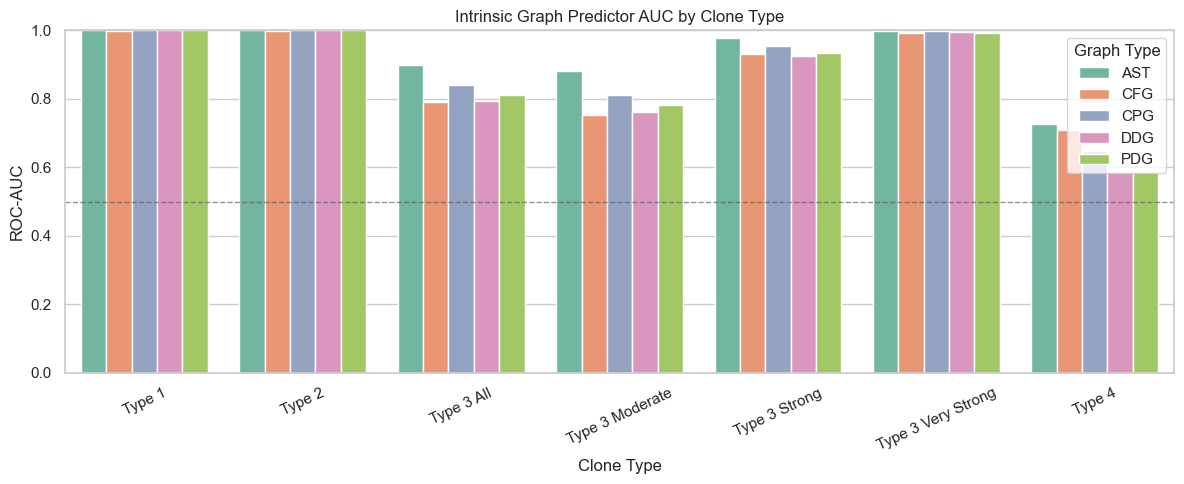

graph_type,AST,CFG,CPG,DDG,PDG
clone_group,,,,,
Type 1,1.000000,0.998524,1.000000,1.000000,1.000000
Type 2,1.000000,0.998179,1.000000,1.000000,1.000000
Type 3 All,0.900317,0.789480,0.839829,0.794064,0.812243
Type 3 Moderate,0.880569,0.754172,0.811407,0.760545,0.780848
Type 3 Strong,0.977392,0.930972,0.954990,0.924796,0.934490
Type 3 Very Strong,0.998764,0.993261,0.997238,0.994903,0.993846
Type 4,0.726457,0.709107,0.648667,0.586101,0.587761


In [18]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=roc_summary_df, x="clone_group", y="auc", hue="graph_type", palette="Set2")
ax.axhline(0.5, **RANDOM_BASELINE_KWARGS)
ax.set_xlabel("Clone Type")
ax.set_ylabel("ROC-AUC")
ax.set_title("Intrinsic Graph Predictor AUC by Clone Type")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Graph Type")
plt.tight_layout()
plt.show()

display(roc_summary_df.pivot_table(index="clone_group", columns="graph_type", values="auc"))